## 丢弃法 Drop out

## 动机

- 一个好的模型需要对输入数据的扰动鲁棒
    - 使用有噪音的数据等价于 Tikhonov 正则
    - 丢弃法：在层之间加入噪音

## 无偏差的加入噪音

- 对 $\mathbf{x}$ 加入噪音得到 $\mathbf{x}'$，我们希望

$$
\mathbb{E}[\mathbf{x}'] = \mathbf{x}
$$

- 丢弃法对每个元素进行如下扰动：

$$
 x'_i = \begin{cases}
 0 & \text{with probability } p \\
 \frac{x_i}{1-p} & \text{otherwise}
 \end{cases}
$$

## 使用丢弃法

- 通常将丢弃法作用在隐藏全连接层的输出上

$$
\mathbf{h} = \sigma(\mathbf{W}_1 \mathbf{x} + \mathbf{b}_1)
$$
$$
\mathbf{h}' = \text{dropout}(\mathbf{h})
$$
$$
\mathbf{o} = \mathbf{W}_2 \mathbf{h}' + \mathbf{b}_2
$$
$$
\mathbf{y} = \text{softmax}(\mathbf{o})
$$

> MLP结构如图所示，丢弃法在隐藏层后对部分神经元进行随机屏蔽。

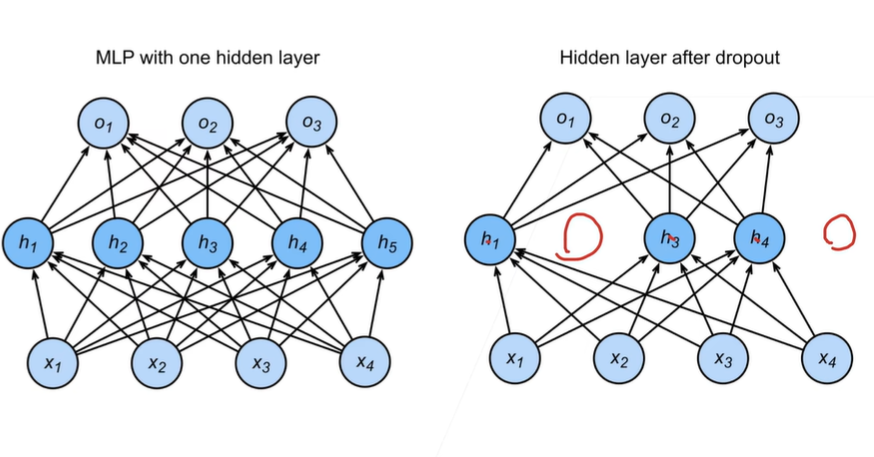

## 推理中的丢弃法

- 正则项只在训练中使用：它们影响模型参数的更新
- 在推理过程中，丢弃法直接返回输入

$$
\mathbf{h} = \text{dropout}(\mathbf{h})
$$

- 这样也能保证确定性的输出

## 总结

- 丢弃法将一些输出项随机置0来控制模型复杂度
- 常作用在多层感知机的隐藏层输出上
- 丢弃概率是控制模型复杂度的超参数

## 代码实现

In [14]:
import torch
from torch import nn
import numpy as np

def dropout(X, dropout):
    assert 0 <= dropout <= 1
    if dropout == 1:
        return torch.zeros_like(X)
    if dropout == 0:
        return X
    mask = (torch.randn(X.shape) > dropout).float()
    return mask * X / (1.0 - dropout)


In [15]:
X = torch.arange(16, dtype = torch.float32).reshape((2, 8))
print(X)
print(dropout(X, 0.))
print(dropout(X, 0.5))
print(dropout(X, 1.))

tensor([[ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11., 12., 13., 14., 15.]])
tensor([[ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11., 12., 13., 14., 15.]])
tensor([[ 0.,  2.,  0.,  6.,  0.,  0., 12.,  0.],
        [16.,  0.,  0.,  0.,  0., 26.,  0.,  0.]])
tensor([[0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.]])


#### 定义有两个隐藏层的多层感知机，每个隐藏层包含256个单元

In [16]:
num_inputs, num_outputs, num_hiddens1, num_hiddens2 = 784, 10, 256, 256
dropout1, dropout2 = 0.2, 0.5

class Net(nn.Module):
    def __init__(self, num_inputs, num_outputs, num_hiddens1, num_hiddens2,
                 dropout1, dropout2, is_training = True ):
        super(Net, self).__init__()
        self.dropout1 = dropout1
        self.dropout2 = dropout2
        self.linear1 = nn.Linear(num_inputs, num_hiddens1)
        self.linear2 = nn.Linear(num_hiddens1, num_hiddens2)
        self.linear3 = nn.Linear(num_hiddens2, num_outputs)
        self.relu = nn.ReLU()
    def forward(self, X):
        H1 = self.relu(self.linear1(X.reshape((-1, self.linear1.in_features))))
        if self.training == True:
            H1 = dropout(H1, self.dropout1)
        H2 = self.relu(self.linear2(H1))
        if self.training == True:
            H2 = dropout(H2, self.dropout2)
        out = self.linear3(H2)
        return out
net = Net(num_inputs, num_outputs, num_hiddens1, num_hiddens2, dropout1, dropout2)


#### 简洁实现

In [ ]:
net = nn.Sequential(
    nn.Linear(num_inputs, num_hiddens1), nn.ReLU(),
    nn.Dropout(dropout1),
    nn.Linear(num_hiddens1, num_hiddens2), nn.ReLU(),
    nn.Dropout(dropout2),
    nn.Linear(num_hiddens2, num_outputs)
)   

# 初始化权重
def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, std=0.01)


net.apply(init_weights)